# Notebook 03: Student Perception and Advanced Classification

## 1. Project Context and Objective
In this notebook, we evaluate how student perception regarding the exam correlates with institutional success. We transform our target variable into a **Classification task** (High vs. Low performance based on the median score). 

Using the first perception question from **Arquivo 3**, we train and compare three classic machine learning models studied in our course: **Naïve Bayes, Decision Trees, and Random Forests**.

## 2. Setup and Data Loading

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

PROCESSED_PATH = '../data/processed/'
RAW_PATH = '../data/raw/'

df_base = pd.read_csv(os.path.join(PROCESSED_PATH, 'enamed_2025_aggregated_performance.csv'))
print(f"Base dataset loaded with {df_base.shape[0]} courses.")

Base dataset loaded with 350 courses.


## 3. Feature Engineering & Target Discretization
We isolate the primary student perception question from Arquivo 3, compute its percentage distribution per course, and split the target score into binary classes (1 for Above Median, 0 for Below Median).

In [28]:
filename = 'microdados_enade_2025_arq3.txt'
df_arq3 = pd.read_csv(os.path.join(RAW_PATH, filename), sep=';', decimal='.')

df_present = df_arq3[df_arq3['TP_PR_GER'] == 555].copy()
target_question = [col for col in df_present.columns if 'CO_RS_' in col or 'PERCEPCAO' in col][0]

perception_features = pd.crosstab(df_present['CO_CURSO'], df_present[target_question], normalize='index') * 100
perception_features.columns = [f'pct_response_{col}' for col in perception_features.columns]
perception_features = perception_features.reset_index()

df_ml = pd.merge(df_base, perception_features, on='CO_CURSO', how='inner')
df_ml = df_ml.fillna(df_ml.median(numeric_only=True))

median_score = df_ml['avg_score_general'].median()
df_ml['performance_class'] = np.where(df_ml['avg_score_general'] >= median_score, 1, 0)

print(f"Target Question selected: {target_question}")
print(df_ml['performance_class'].value_counts())

Target Question selected: CO_RS_I1
performance_class
1    175
0    175
Name: count, dtype: int64


## 4. Data Pre-processing & Feature Scaling
Splitting features ($X$) and labels ($y$), dividing the dataset into training (80%) and testing (20%) sets, and applying `StandardScaler`.

In [29]:
feature_cols = [col for col in df_ml.columns if 'pct_response_' in col]
X = df_ml[feature_cols]
y = df_ml['performance_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Pre-processing complete. Features scaled: {len(feature_cols)}")

Pre-processing complete. Features scaled: 7


## 5. Model Training, Comparison & Confusion Matrix
Training Naïve Bayes, a Decision Tree, and a Random Forest, followed by plotting the Confusion Matrix of the best performing model.

Naïve Bayes Accuracy: 0.6857
Decision Tree Accuracy: 0.6857
Random Forest Accuracy: 0.7286


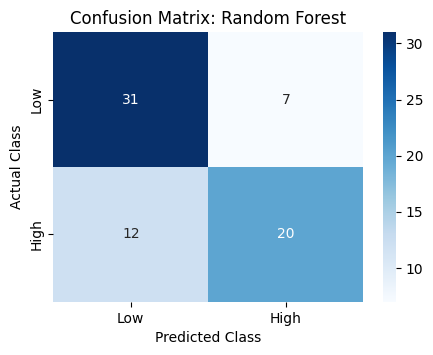

In [30]:
classifiers = {
    "Naïve Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=4),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=4)
}

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"model": clf, "accuracy": acc, "predictions": y_pred}
    print(f"{name} Accuracy: {acc:.4f}")

best_model_name = max(results, key=lambda k: results[k]['accuracy'])
y_pred_best = results[best_model_name]['predictions']

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

## 6. Institutional Prediction (Focus: UFJF)
Predicting the performance class for both UFJF campuses using exclusively the student perception profile.

In [31]:
df_ufjf = df_ml[df_ml['is_ufjf'] == True]
best_clf = results[best_model_name]['model']

class_labels = {0: "Low Performance", 1: "High Performance"}

for idx, row in df_ufjf.iterrows():
    campus = "Juiz de Fora (13103)" if row['CO_CURSO'] == 13103 else "Governador Valadares (5001167)"
    
    ufjf_features = pd.DataFrame([row[feature_cols]], columns=feature_cols)
    ufjf_features_scaled = scaler.transform(ufjf_features)
    
    pred = best_clf.predict(ufjf_features_scaled)[0]
    prob = best_clf.predict_proba(ufjf_features_scaled)[0]
    
    print(f"\nCampus: {campus}")
    print(f"Prediction: {class_labels[pred]} ({prob[pred]*100:.1f}% confidence)")
    print(f"Actual Exam Class: {class_labels[row['performance_class']]}")


Campus: Juiz de Fora (13103)
Prediction: Low Performance (61.4% confidence)
Actual Exam Class: High Performance

Campus: Governador Valadares (5001167)
Prediction: High Performance (73.7% confidence)
Actual Exam Class: High Performance
